# Задача 1.11

## 1. Условие


Используя графические возможности Jupyter Notebook, изобразить матрицу размера $n\times n$ для $n=100$, каждая строка которой содержит биномиальные коэффициенты по модулю 2.

Закрашенный **синий** квадратик соответствует 1, **жёлтый** — 0.

Например, для $n=3$:

$$
\begin{pmatrix}
C_1^1&0&0\\
C_2^1&C_2^2&0\\
C_3^1&C_3^2&C_3^3
\end{pmatrix}\pmod 2
=
\begin{pmatrix}
1&0&0\\
0&1&0\\
1&1&1
\end{pmatrix}.
$$


## 2. Теоретическая часть


**Биномиальный коэффициент** вычисляется по формуле

$$
C_n^k=\binom{n}{k}=\frac{n!}{k!(n-k)!}.
$$

В Python значение $C_i^j$ можно получить функцией `comb(i, j)`.

**Взятие по модулю 2** означает, что нас интересует остаток от деления на 2:

$$
C_i^j\bmod2=
\begin{cases}
0, & C_i^j \text{ чётное},\\
1, & C_i^j \text{ нечётное}.
\end{cases}
$$

В строке с номером $i$ нужны коэффициенты $C_i^1,C_i^2,\ldots,C_i^i$, поэтому заполняется только нижняя треугольная часть матрицы. Область выше главной диагонали не относится к вычисляемым коэффициентам и скрывается при визуализации.


## 3. Решение

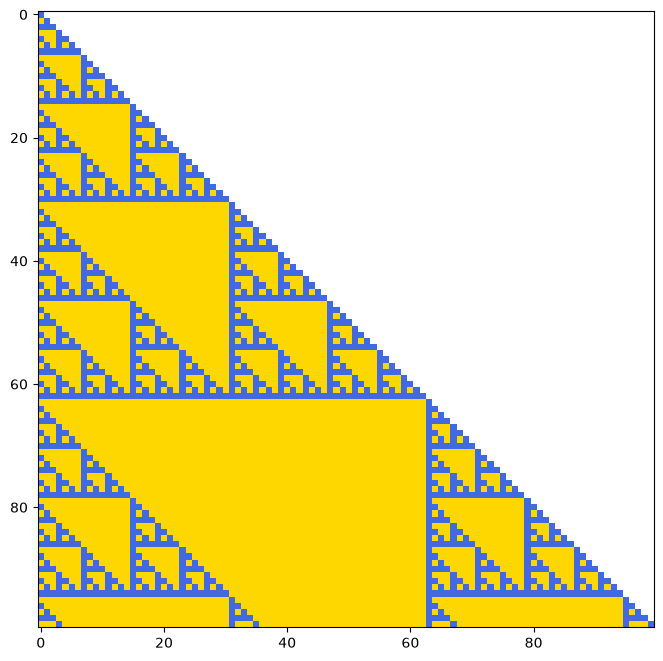

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from math import comb

def task11():
    # Размер матрицы
    n = 100

    # Создаём матрицу и заполняем её нулями размерами NxN
    # dtype=int говорит NumPy: создай матрицу из целых чисел. по умолчанию создает float
    matrix = np.zeros((n, n), dtype=int)

    # Заполняем нижнюю треугольную часть
    # биномиальными коэффициентами по модулю 2
    # проще говоря: такой вариант позволяет заполнять только нижнюю часть
    # а присваиваем мы значение либо 0, либо 1 (делим i, j на 2 и берем остаток)
    for i in range(1, n + 1):
        for j in range(1, i + 1):
            matrix[i - 1, j - 1] = comb(i, j) % 2

    # Скрываем область выше главной диагонали,
    # чтобы оформление соответствовало примеру из задания
    # нужно это для того, чтобы не смешивать исходные нули (когда создавали матрицу)
    # с вычисленными нулями (которые мы вычислили как остаток от деления в строке 20)
    mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    matrix_for_plot = np.ma.array(matrix, mask=mask)

    # 0 — жёлтый, 1 — синий
    cmap = ListedColormap(["gold", "royalblue"])
    cmap.set_bad("white")

    # Строим изображение матрицы
    plt.figure(figsize=(8, 8))
    plt.imshow(matrix_for_plot, cmap=cmap, interpolation="nearest")

    plt.show()

task11()

## 4. Ответ


Построена матрица размера $100\times100$ из значений $C_i^j\bmod2$:

- значение **1** отображается синим цветом;
- значение **0** отображается жёлтым цветом;
- область выше главной диагонали скрыта, так как она не содержит вычисляемых биномиальных коэффициентов.

Результат отображён на графике, сформированном кодом выше.
